1. f(x) = cx **2 + d
2. c = -5
3. d = 5
4. a = 0
5. b = 4
6. N = 16
7. A = 2

МНК
c = -5.0277,  d = 5.1030,  СКО = 0.6437

 НС (Видроу-Хофф, η=0.001)
Epoch 0: c = -2.8737, d = -0.2728, E² = 9533.357371
Epoch 1: c = -3.9379, d = -0.3479, E² = 1422.444906
Epoch 2: c = -4.3334, d = -0.3502, E² = 365.066583
Epoch 3: c = -4.4817, d = -0.3257, E² = 237.353583
Epoch 4: c = -4.5387, d = -0.2915, E² = 224.269077
Epoch 5: c = -4.5619, d = -0.2539, E² = 222.335139
Epoch 6: c = -4.5726, d = -0.2153, E² = 220.295963
Epoch 7: c = -4.5787, d = -0.1764, E² = 217.669960
Epoch 8: c = -4.5830, d = -0.1376, E² = 214.778501
Epoch 9: c = -4.5867, d = -0.0991, E² = 211.807223
Epoch 10: c = -4.5901, d = -0.0608, E² = 208.833154
Epoch 11: c = -4.5934, d = -0.0227, E² = 205.885428
Epoch 12: c = -4.5967, d = 0.0150, E² = 202.974508
Epoch 13: c = -4.5999, d = 0.0525, E² = 200.103863
Epoch 14: c = -4.6031, d = 0.0897, E² = 197.274378
Epoch 15: c = -4.6063, d = 0.1266, E² = 194.485990
Epoch 16: c = -4.6094, d = 0.1633, E² = 191.738299
Epoch 17: c = -4.6126, d = 0.1996, E² = 189.030781
Epoch 

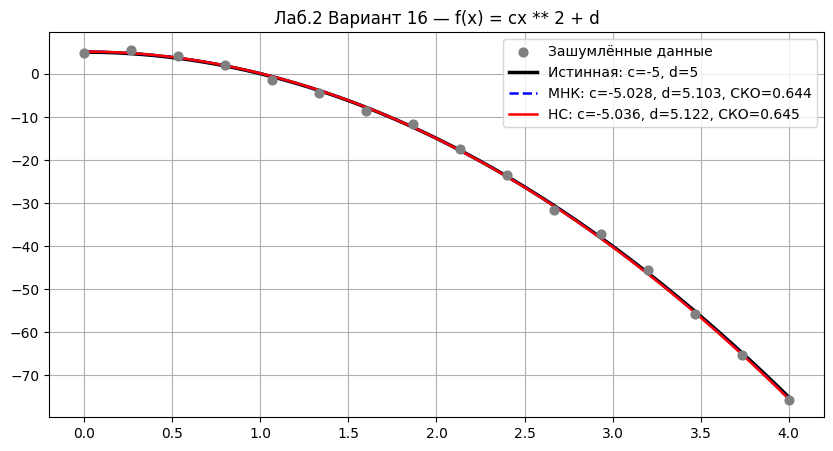

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


C_TRUE = -5      # истинный коэффициент 
D_TRUE = 5       # истинный коэффициент
A_START = 0      # начало интервала [a, b]
B_END = 4        # конец интервала
N = 16           # Точки
A_NOISE = 2      # шума

np.random.seed(42)   # фиксируем генератор ,чтобы результаты были воспроизводимым

def generate_dataset():
    x_points = np.linspace(A_START, B_END, N)
    dataset = []
    for xi in x_points:
        zi = xi ** 2                             # замена переменной z = x ** 2 
        ei = A_NOISE * (np.random.rand() - 0.5)  # шум: A·rnd(-0.5, 0.5) 
        ti = C_TRUE * zi + D_TRUE + ei           # зашумлённое значение (2.4) по методичке
        dataset.append((xi, zi, ti))
    return dataset

def mnk(dataset):
    # Формула (2.3) из методички — МНК по переменной z = x ** 2
    n = len(dataset)
    sum_z  = sum(zi for xi, zi, ti in dataset)          # сумма zi
    sum_t  = sum(ti for xi, zi, ti in dataset)          # сумма ti
    sum_zt = sum(zi * ti for xi, zi, ti in dataset)     # сумма (zi·ti)
    sum_z2 = sum(zi ** 2 for xi, zi, ti in dataset)     # cумма (zi ** 2)

    # Формула 2.3 из методички, только xi замененa на zi
    c = (n * sum_zt - sum_z * sum_t) / (n * sum_z2 - sum_z ** 2)
    d = (sum_t - c * sum_z) / n
    return c, d

def sko(c, d, dataset):
    n = len(dataset)
    return (sum((c * zi + d - ti) ** 2 for xi, zi, ti in dataset) / n) ** 0.5

class Neuron:
    def __init__(self):
        self.c = 0.0   # вес при входе z = x ** 2 (соответствует коэффициенту c)
        self.d = 0.0   # вес при bias = 1   (соответствует коэффициенту d)

    def output(self, zi):
        # Линейная ФА: y = net = c·z + d
        return self.c * zi + self.d

    def update_weights(self, zi, delta, lr):
        self.c += lr * delta * zi
        self.d += lr * delta # bias = 1


def train_neuron_verbose(neuron, dataset, lr, max_epochs):
    epochs_list = []
    errors_list = []

    for epoch in range(max_epochs):
        E2 = 0.0                            # суммарная квадратичная ошибка (формула 12)

        for xi, zi, ti in dataset:          # предъявляем все N образцов
            yi    = neuron.output(zi)       # выход нейрона для входа zi
            delta = ti - yi                
            E2   += delta ** 2              # накапливаем квадраты ошибок для всех образцов 
            neuron.update_weights(zi, delta, lr)  # корректируем c и d

        epochs_list.append(epoch)
        errors_list.append(E2)
        print(f"Epoch {epoch}: c = {neuron.c:.4f}, d = {neuron.d:.4f}, E² = {E2:.6f}")

        if epoch > 0 and abs(errors_list[-1] - errors_list[-2]) == 0: #< 1e-8:
            break

if __name__ == "__main__":
    dataset = generate_dataset()  

    c_mnk, d_mnk = mnk(dataset)             
    sko_mnk = sko(c_mnk, d_mnk, dataset)
    print("МНК")    
    print(f"c = {c_mnk:.4f},  d = {d_mnk:.4f},  СКО = {sko_mnk:.4f}")


    print("\n НС (Видроу-Хофф, η=0.001)")
    neuron = Neuron()                                # начальные веса c=0, d=0

    train_neuron_verbose(neuron, dataset, lr=0.001, max_epochs=10000)
    sko_nn = sko(neuron.c, neuron.d, dataset)
    print(f"\n c = {neuron.c:.4f},  d = {neuron.d:.4f},  СКО = {sko_nn:.4f}")
    

    x = np.linspace(A_START, B_END, 300) # 300 точек от 0 до 4 для гладкого графика
    z= x ** 2

    x_data = [xi for xi, zi, ti in dataset]         # исходные x для точек
    t_data = [ti for xi, zi, ti in dataset]         # зашумлённые значения

    plt.figure(figsize=(10, 5))

    plt.scatter(x_data, t_data, color='gray', s=40, zorder=5,
                label='Зашумлённые данные')
    
    plt.plot(x, C_TRUE * z + D_TRUE, 'k-', linewidth=2.5,
             label=f'Истинная: c={C_TRUE}, d={D_TRUE}')
    
    plt.plot(x, c_mnk * z + d_mnk, 'b--', linewidth=1.8,
             label=f'МНК: c={c_mnk:.3f}, d={d_mnk:.3f}, СКО={sko_mnk:.3f}')
    
    plt.plot(x, neuron.c * z + neuron.d, 'r-', linewidth=1.8,
             label=f'НС: c={neuron.c:.3f}, d={neuron.d:.3f}, СКО={sko_nn:.3f}')
    
 
    plt.title('Лаб.2 Вариант 16 — f(x) = cx ** 2 + d')
    plt.legend()
    plt.grid()
    plt.show()